In [20]:
# Import Chicago Crimes db
import pandas as pd

# Base API endpoint
base_url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv"

# Years
years = [2005, 2015, 2025]

# Store results
dfs = []

# Columns to keep
columns = [
    "id",
    "date",
    "primary_type",
    "latitude",
    "longitude"
]

select_clause = ",".join(columns)

# Loop through each year
for y in years:
    offset = 0
    
    while True:
        url = (
            f"{base_url}?"
            f"$select={select_clause}"
            f"&$where=year={y}"
            f"&$limit=50000"
            f"&$offset={offset}"
        )
        
        print(f"Loading year {y}, offset {offset}...")
        
        chunk = pd.read_csv(url)
        
        # Stop when no more data
        if chunk.empty:
            print(f"Finished year {y}")
            break
        
        dfs.append(chunk)
        offset += 50000

# Combine all data
df = pd.concat(dfs, ignore_index=True)

print("Final dataset shape:", df.shape)

Loading year 2005, offset 0...
Loading year 2005, offset 50000...
Loading year 2005, offset 100000...
Loading year 2005, offset 150000...
Loading year 2005, offset 200000...
Loading year 2005, offset 250000...
Loading year 2005, offset 300000...
Loading year 2005, offset 350000...
Loading year 2005, offset 400000...
Loading year 2005, offset 450000...
Loading year 2005, offset 500000...
Finished year 2005
Loading year 2015, offset 0...
Loading year 2015, offset 50000...
Loading year 2015, offset 100000...
Loading year 2015, offset 150000...
Loading year 2015, offset 200000...
Loading year 2015, offset 250000...
Loading year 2015, offset 300000...
Finished year 2015
Loading year 2025, offset 0...
Loading year 2025, offset 50000...
Loading year 2025, offset 100000...
Loading year 2025, offset 150000...
Loading year 2025, offset 200000...
Loading year 2025, offset 250000...
Finished year 2025
Final dataset shape: (955533, 5)


In [21]:
import numpy as np

# Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Convert Latitude and Longitude
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Convert Date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Drop rows with missing Date, Latitude, Longitude
df = df.dropna(subset=["date", "latitude", "longitude"])

# Ensure year column exists
df["year"] = df["date"].dt.year

# Remove invalid geographic coordinates (Chicago bounds)
df = df[
    (df["latitude"].between(41.6, 42.1)) &
    (df["longitude"].between(-88, -87.5))
]

# Remove duplicate records using ID
if "id" in df.columns:
    df = df.drop_duplicates(subset=["id"])

# Standardize crime type text
if "primary_type" in df.columns:
    df["primary_type"] = df["primary_type"].str.upper().str.strip()

# Filter for gang-related proxy crimes
gang_related_types = [
    "HOMICIDE",
    "ASSAULT",
    "BATTERY",
    "WEAPONS VIOLATION",
    "ROBBERY"
]

if "primary_type" in df.columns:
    df = df[df["primary_type"].isin(gang_related_types)]

# Keep only relevant columns
columns_to_keep = [
    "id", "date", "year",
    "latitude", "longitude",
    "primary_type",
]

df = df[[col for col in columns_to_keep if col in df.columns]]

# Reset index after all filtering
df = df.reset_index(drop=True)

# Check dataset shape
print("Shape:", df.shape)

# Check year distribution
print(df["year"].value_counts().sort_index())

# Check missing values
print(df.isna().sum())

# Check duplicate IDs
if "id" in df.columns:
    print("Duplicate IDs:", df["id"].duplicated().sum())

# Prepare coordinates for clustering and convert to radians
coords = df[["latitude", "longitude"]].to_numpy()
coords_rad = np.radians(coords)

# Split dataset by year
df_2005 = df[df["year"] == 2005]
df_2015 = df[df["year"] == 2015]
df_2025 = df[df["year"] == 2025]

# Prepare coordinates per year
coords_2005 = np.radians(df_2005[["latitude", "longitude"]].to_numpy())
coords_2015 = np.radians(df_2015[["latitude", "longitude"]].to_numpy())
coords_2025 = np.radians(df_2025[["latitude", "longitude"]].to_numpy())

Shape: (285991, 6)
year
2005    131116
2015     79275
2025     75600
Name: count, dtype: int64
id              0
date            0
year            0
latitude        0
longitude       0
primary_type    0
dtype: int64
Duplicate IDs: 0


In [22]:
# Find descriptive statistics

print(df.columns.tolist())

# Mode for primary_type (safe)
primary_mode = df["primary_type"].mode()

if not primary_mode.empty:
    print("Most common crime type:", primary_mode.iloc[0])

# Mean for latitude and longitude
print("Latitude mean:", df["latitude"].mean())
print("Longitude mean:", df["longitude"].mean())

# Median for latitude and longitude
print("Latitude median:", df["latitude"].median())
print("Longitude median:", df["longitude"].median())

# Range for latitude and longitude
lat_range = df["latitude"].max() - df["latitude"].min()
lon_range = df["longitude"].max() - df["longitude"].min()

print("Latitude range:", lat_range)
print("Longitude range:", lon_range)

['id', 'date', 'year', 'latitude', 'longitude', 'primary_type']
Most common crime type: BATTERY
Latitude mean: 41.83190536804757
Longitude mean: -87.66825535252896
Latitude median: 41.827265715
Longitude median: -87.663547848
Latitude range: 0.3779673319999972
Longitude range: 0.4004403200000013


In [23]:
# Confirm accuracy of mode crime type

df["primary_type"].value_counts().head()

primary_type
BATTERY              174890
ASSAULT               65468
ROBBERY               31409
WEAPONS VIOLATION     12841
HOMICIDE               1383
Name: count, dtype: int64

In [24]:
# import FBI crime dataset
file_path = r"C:\\Users\\Henry\\Desktop\\fbi_crimes.csv"

df_fbi = pd.read_csv(file_path)


print(df_fbi.head())
print(df_fbi.columns.tolist())
print(df_fbi.shape)

   _id  year  population  violent_crime  violent_crime_rate  murder  \
0    1  2005   296410404        1445266               487.6   17598   
1    2  2006   299398484        1429739               477.5   17190   
2    3  2007   301621157        1425843               472.7   17264   
3    4  2008   304059724        1387179               456.2   16382   
4    5  2009   307006550        1321763               430.5   15426   

   murder_rate  robbery  robbery_rate  aggravated_assault  ...  burglary_rate  \
0          5.9   445680         150.4              891190  ...          738.9   
1          5.7   449537         150.1              873908  ...          732.6   
2          5.7   450460         149.3              871190  ...          728.3   
3          5.4   443633         145.9              842336  ...          732.0   
4          5.0   409172         133.3              811786  ...          717.6   

   larceny_theft  larceny_theft_rate  motor_vehicle_theft  \
0        6866515         

In [38]:
# Drop irrelevant columns
cols_to_keep = ["year", "violent_crime_rate", "total_crime_rate"]
df_fbi = df_fbi[cols_to_keep]


print(df_fbi.head())
print(df_fbi.shape)

   year  violent_crime_rate  total_crime_rate
0  2005               487.6       3973.845331
1  2006               477.5       3817.168293
2  2007               472.7       3756.094935
3  2008               456.2       3660.123693
4  2009               430.5       3463.396139
(20, 3)


In [26]:
# Find descriptive statistics

# Mean
print("Violent Crime Rate mean:", df_fbi["violent_crime_rate"].mean())
print("Total Crime Rate mean:", df_fbi["total_crime_rate"].mean())

# Median
print("Violent Crime Rate median:", df_fbi["violent_crime_rate"].median())
print("Total Crime Rate median:", df_fbi["total_crime_rate"].median())

# Range
violent_range = df_fbi["violent_crime_rate"].max() - df_fbi["violent_crime_rate"].min()
total_range   = df_fbi["total_crime_rate"].max() - df_fbi["total_crime_rate"].min()

print("Violent Crime Rate range:", violent_range)
print("Total Crime Rate range:", total_range)

Violent Crime Rate mean: 403.63
Total Crime Rate mean: 2971.5500955217385
Violent Crime Rate median: 388.1
Total Crime Rate median: 2901.2737545330597
Violent Crime Rate range: 128.5
Total Crime Rate range: 1854.6121235315031


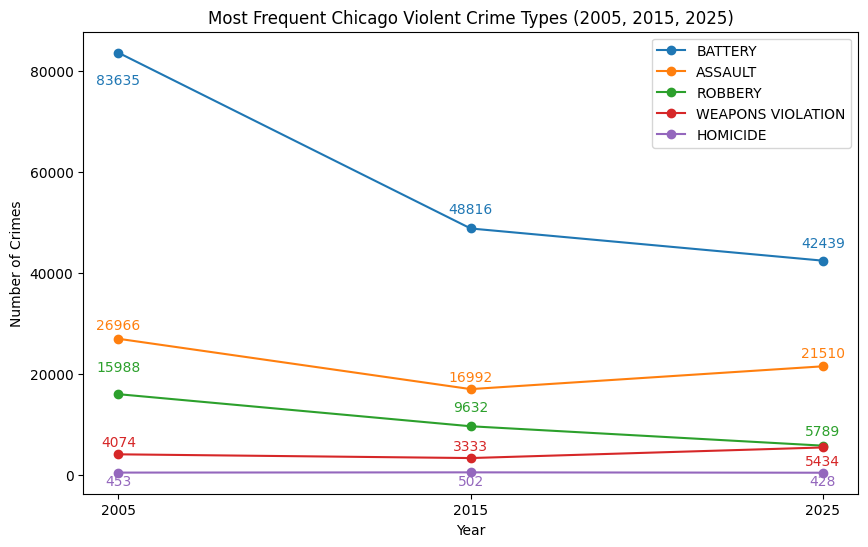

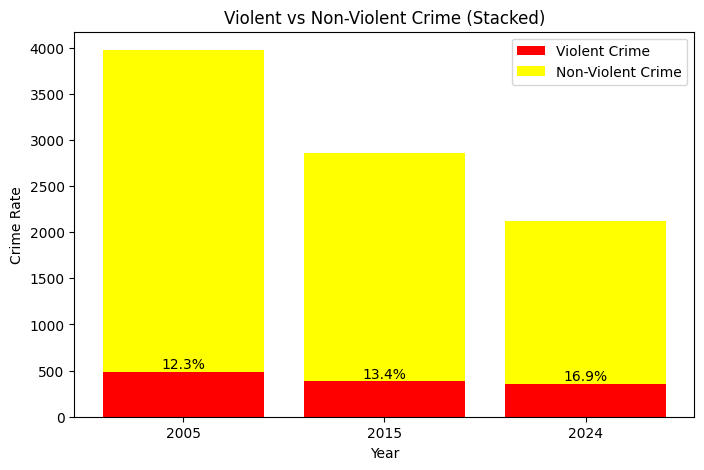

In [27]:
# Visualize trends in the inital datasets
import matplotlib.pyplot as plt
import numpy as np

# Types of crime in Chicago by year
import matplotlib.pyplot as plt

# Filter to only the years of interest
years = [2005, 2015, 2025]
df_filtered = df[df["year"].isin(years)]

# Group data by year and primary crime type
crime_counts = (
    df_filtered
    .groupby(["year", "primary_type"])
    .size()
    .reset_index(name="count")
)

# Find the 5 most common crime types overall
top_types = (
    df_filtered["primary_type"]
    .value_counts()
    .head(5)
    .index
)

plt.figure(figsize=(10, 6))

# Loop through each top crime type
for crime_type in top_types:
    
    # Extract data for this crime type
    subset = crime_counts[crime_counts["primary_type"] == crime_type]
    
    # Plot the line and capture its color
    line, = plt.plot(
        subset["year"].astype(int),
        subset["count"],
        marker='o',
        label=crime_type
    )
    
    color = line.get_color()
    
    # Loop through each data point for labeling
    for _, row in subset.iterrows():
        
        year = int(row["year"])
        count = row["count"]
        
        # Default label position
        y_pos = count * 1.05

        # Move Battery 2005 label lower so it fits on plot
        if crime_type.lower() == "battery" and year == 2005:
            y_pos = count * 0.95
        
        # Move homicide labels below the line
        if crime_type.lower() == "homicide":
            y_pos = count * 0.01
        
        # Move robbery labels higher above the line
        elif crime_type.lower() == "robbery":
            y_pos = count * 1.25
        
        # Special handling for weapons violation
        elif crime_type.lower() == "weapons violation":
            
            # Move 2025 label below the line
            if year == 2025:
                y_pos = count * 0.75
            
            # Move other years higher above the line
            else:
                y_pos = count * 1.25
        
        # Add the label with matching color
        plt.text(
            year,
            y_pos,
            int(count),
            ha='center',
            va='bottom' if y_pos > count else 'top',
            fontsize=10,
            color=color
        )

# Set x-axis to only show the selected years as integers
plt.xticks(years, [int(y) for y in years])

# Label axes and title
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.title("Most Frequent Chicago Violent Crime Types (2005, 2015, 2025)")
plt.legend()
plt.show()



# National percentage of violent crime per year
crime_trend = (
    df_fbi
    .groupby("year")[["violent_crime_rate", "total_crime_rate"]]
    .mean()
    .reset_index()
)

# Filter to the three years of interest
years = [2005, 2015, 2024]
filtered = crime_trend[crime_trend["year"].isin(years)].copy()

# Compute non-violent portion
filtered["non_violent"] = filtered["total_crime_rate"] - filtered["violent_crime_rate"]

# Compute percentage of violent crime
filtered["violent_pct"] = (
    filtered["violent_crime_rate"] / filtered["total_crime_rate"]
) * 100

# Positions for bars
x = np.arange(len(filtered))

# Create stacked bar chart
plt.figure(figsize=(8, 5))

# Violent crime (bottom, red)
plt.bar(x, filtered["violent_crime_rate"], color="red", label="Violent Crime")

# Non-violent (top, yellow)
plt.bar(x, filtered["non_violent"], bottom=filtered["violent_crime_rate"], color="yellow", label="Non-Violent Crime")

# Odd percentage labels on top of violent portion
for i in range(len(filtered)):
    plt.text(
        x[i],
        filtered["violent_crime_rate"].iloc[i],
        f'{filtered["violent_pct"].iloc[i]:.1f}%',
        ha='center',
        va='bottom'
    )

# Format x-axis
plt.xticks(x, filtered["year"])

plt.xlabel("Year")
plt.ylabel("Crime Rate")
plt.title("Violent vs Non-Violent Crime (Stacked)")
plt.legend()

plt.show()

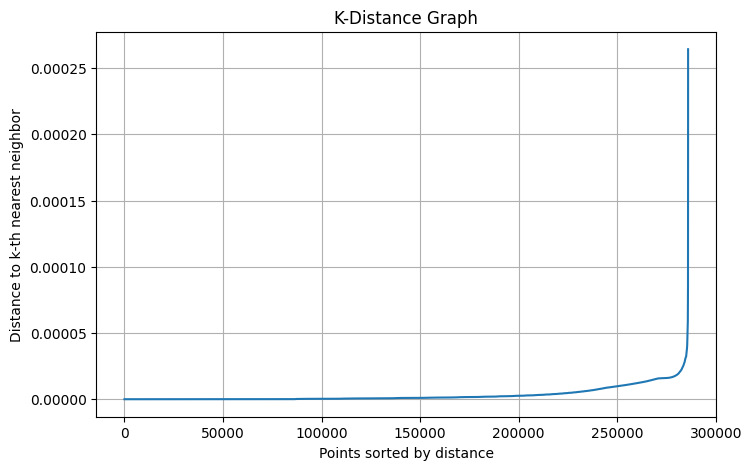


Testing EPS = 2e-05
2005: clusters=620, noise=3993
2015: clusters=747, noise=5230
2025: clusters=940, noise=5392

Testing EPS = 5e-05
2005: clusters=24, noise=160
2015: clusters=32, noise=255
2025: clusters=37, noise=240

Testing EPS = 0.0001
2005: clusters=7, noise=18
2015: clusters=8, noise=25
2025: clusters=8, noise=26

Testing EPS = 0.0002
2005: clusters=2, noise=2
2015: clusters=3, noise=8
2025: clusters=3, noise=1

Testing EPS = 0.0005
2005: clusters=2, noise=0
2015: clusters=1, noise=0
2025: clusters=1, noise=0


In [28]:
# DBSCAN model development


from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


# Feature selection

gang_crimes = [
    "HOMICIDE",
    "ASSAULT",
    "BATTERY",
    "ROBBERY",
    "WEAPONS VIOLATION"
]

df_gang = df[df["primary_type"].isin(gang_crimes)].copy()

# K-Distance graph for model tuning

coords = df_gang[["latitude", "longitude"]].to_numpy()
coords_rad = np.radians(coords)

k = 6

nbrs = NearestNeighbors(n_neighbors=k, metric="haversine")
nbrs.fit(coords_rad)

distances, _ = nbrs.kneighbors(coords_rad)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title("K-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to k-th nearest neighbor")
plt.grid(True)
plt.show()

# DBSCAN parameter testing

eps_values = [0.00002, 0.00005, 0.0001, 0.0002, 0.0005]

for EPS in eps_values:
    print(f"\nTesting EPS = {EPS}")
    
    for year in [2005, 2015, 2025]:
        df_year = df_gang[df_gang["year"] == year].copy()
        
        coords = df_year[["latitude", "longitude"]].to_numpy()
        coords_rad = np.radians(coords)
        
        db = DBSCAN(eps=EPS, min_samples=6, metric="haversine")
        labels = db.fit_predict(coords_rad)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)
        
        print(f"{year}: clusters={n_clusters}, noise={noise}")

In [29]:
# Run developed DBSCAN Model
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
import numpy as np

EPS = 0.00005 # Most appropriate eps based on above testing
MIN_SAMPLES = 6

df_gang["cluster"] = -1

years = [2005, 2015, 2025]

# loop through each year to apply dbscan separately
for year in years:
    
    df_year = df_gang[df_gang["year"] == year].copy()
    
    if df_year.empty:
        continue

# Extract latitude and longitude coordinates
    coords = df_year[["latitude", "longitude"]].to_numpy()
    coords_rad = np.radians(coords) # Convert coordinates to radians for haversine distance calculation
    
    db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric="haversine")
    labels = db.fit_predict(coords_rad)
    
    df_gang.loc[df_year.index, "cluster"] = labels
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    
    print(f"{year}: {n_clusters} clusters, {noise} noise points")

2005: 24 clusters, 160 noise points
2015: 32 clusters, 255 noise points
2025: 37 clusters, 240 noise points


In [30]:
# Employ stabliity-based cross-validation to measure DBSCAN hotspot robustness

eps = 0.00005
min_samples = 6

# Store results
stability_scores = []

# Run multiple iterations
for i in range(10):
    
    # split data
    train_idx, test_idx = train_test_split(
        np.arange(len(coords_rad)), 
        test_size=0.3, 
        random_state=i
    )
    
    train_coords = coords_rad[train_idx]
    test_coords = coords_rad[test_idx]
    
    # Fit DBSCAN on training data
    db = DBSCAN(eps=eps, min_samples=min_samples, metric="haversine")
    train_labels = db.fit_predict(train_coords)
    
    # Evaluate how well test points fit into clusters
    from sklearn.neighbors import NearestNeighbors
    
    core_points = train_coords[train_labels != -1]
    
    if len(core_points) == 0:
        continue
    
# Calculate stability score
    nbrs = NearestNeighbors(metric="haversine").fit(core_points)
    distances, _ = nbrs.kneighbors(test_coords)
    
    stability_scores.append(distances.mean())

print("Average stability score:", np.mean(stability_scores))

# Convert from Radians to Kilometers
EARTH_RADIUS_KM = 6371.0

avg_stability_km = np.mean(stability_scores) * EARTH_RADIUS_KM

print("Average stability score (km):", avg_stability_km)

# Store stability score for later comparison
average_stability = np.mean(stability_scores)

stability_km = avg_stability_km

Average stability score: 8.386732337755507e-06
Average stability score (km): 0.053431871723840334


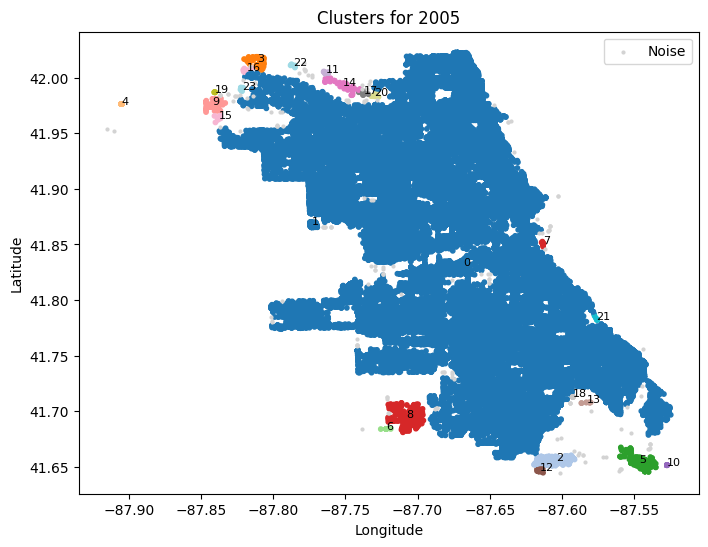

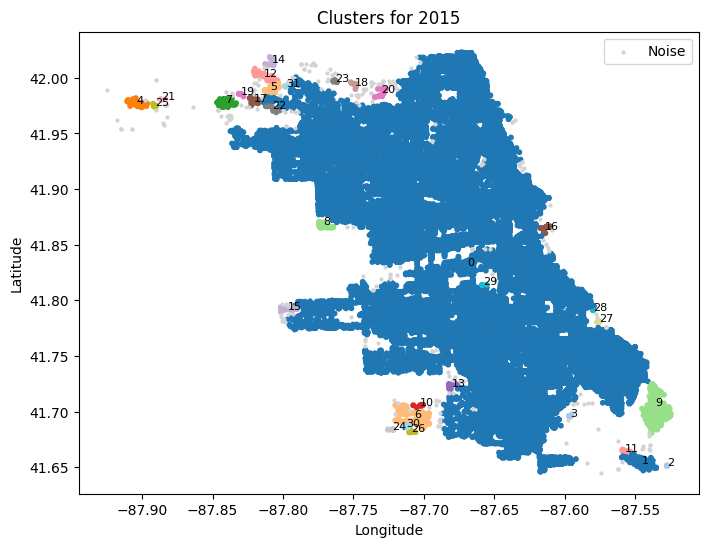

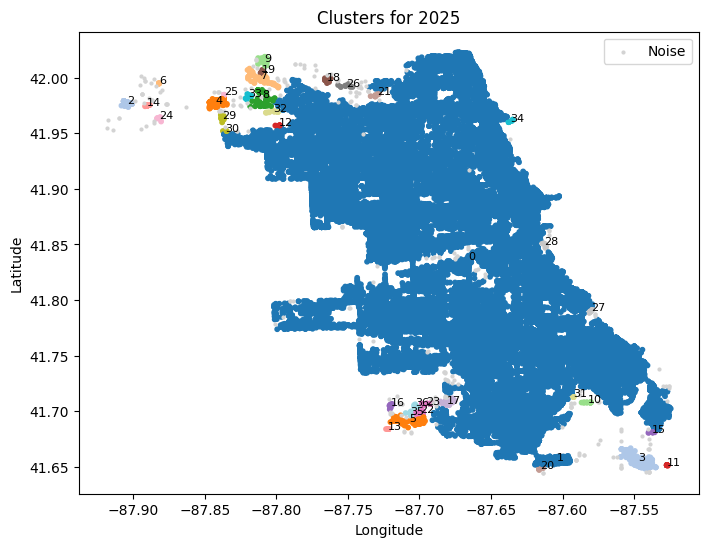

In [31]:
# Visualize DBSCAN hotspots
def plot_with_labels(df_year, year):
    plt.figure(figsize=(8, 6))
    
    # Separate clusters and noise
    clusters = df_year[df_year["cluster"] != -1]
    noise = df_year[df_year["cluster"] == -1]
    
    # Plot clusters
    plt.scatter(
        clusters["longitude"],
        clusters["latitude"],
        c=clusters["cluster"],
        cmap="tab20",
        s=10
    )
    
    # Plot noise in gray
    plt.scatter(
        noise["longitude"],
        noise["latitude"],
        c="lightgray",
        s=4,
        label="Noise"
    )
    
    # Add labels for clusters (centroids)
    centroids = clusters.groupby("cluster")[["latitude", "longitude"]].mean()
    
    for cluster_id, row in centroids.iterrows():
        plt.text(
            row["longitude"],
            row["latitude"],
            str(cluster_id),
            fontsize=8
        )
    
    plt.title(f"Clusters for {year}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.show()


# Run for each year
for year in [2005, 2015, 2025]:
    df_year = df_gang[df_gang["year"] == year]
    plot_with_labels(df_year, year)

In [32]:
# Measure changes in clusters across years

from scipy.spatial.distance import cdist

# Build centroids from clusters


centroids_2005 = df_gang[df_gang["year"] == 2005]
centroids_2005 = centroids_2005[centroids_2005["cluster"] != -1] \
    .groupby("cluster")[["latitude", "longitude"]].mean()

centroids_2015 = df_gang[df_gang["year"] == 2015]
centroids_2015 = centroids_2015[centroids_2015["cluster"] != -1] \
    .groupby("cluster")[["latitude", "longitude"]].mean()

centroids_2025 = df_gang[df_gang["year"] == 2025]
centroids_2025 = centroids_2025[centroids_2025["cluster"] != -1] \
    .groupby("cluster")[["latitude", "longitude"]].mean()

# Match clusters with interpretation
def find_best_matches(c1, c2, threshold=0.002):
    dist = cdist(c1.values, c2.values)
    
    results = []
    
    for i in range(dist.shape[0]):
        j = dist[i].argmin()
        distance = dist[i][j]
        
        if distance < threshold:
            status = "🔵 Persistent (same location)"
        elif distance < 0.01:
            status = "🟡 Slightly shifted"
        else:
            status = "🔴 Different hotspot"
        
        results.append({
            "Cluster (Year 1)": c1.index[i],
            "Cluster (Year 2)": c2.index[j],
            "Distance": round(distance, 6),
            "Status": status
        })
    
    return pd.DataFrame(results)


# Pairwise matching (forward direction)
matches_05_15 = find_best_matches(centroids_2005, centroids_2015)
matches_15_25 = find_best_matches(centroids_2015, centroids_2025)

print("=== 2005 → 2015 Matches ===")
print(matches_05_15.sort_values(by="Distance"))

print("\n=== 2015 → 2025 Matches ===")
print(matches_15_25.sort_values(by="Distance"))


# Build true spatial lineage
def build_spatial_lineage(matches_05_15, matches_15_25):
    lineage = []

    # Mapping: 2015 → 2025
    map_15_25 = {
        row["Cluster (Year 1)"]: row["Cluster (Year 2)"]
        for _, row in matches_15_25.iterrows()
    }

    map_15_25_dist = {
        row["Cluster (Year 1)"]: row["Distance"]
        for _, row in matches_15_25.iterrows()
    }

    for _, row in matches_05_15.iterrows():
        c05 = row["Cluster (Year 1)"]
        c15 = row["Cluster (Year 2)"]
        dist_05_15 = row["Distance"]

        c25 = map_15_25.get(c15, None)
        dist_15_25 = map_15_25_dist.get(c15, None)

        lineage.append({
            "Cluster 2005": c05,
            "Cluster 2015": c15,
            "Cluster 2025": c25,
            "Move 05→15": dist_05_15,
            "Move 15→25": dist_15_25
        })

    return pd.DataFrame(lineage)


lineage = build_spatial_lineage(matches_05_15, matches_15_25)

print("\n=== Cluster Lineage (2005 → 2015 → 2025) ===")
print(lineage)


# Classify each lineage
def classify(row):
    if (
        pd.notna(row["Cluster 2025"]) and
        row["Move 05→15"] < 0.002 and
        row["Move 15→25"] < 0.002
    ):
        return "Persistent"
    
    elif (
        pd.notna(row["Cluster 2025"]) and
        (row["Move 05→15"] >= 0.002 or row["Move 15→25"] >= 0.002)
    ):
        return "Shifting"
    
    else:
        return "Disappeared"


lineage["Type"] = lineage.apply(classify, axis=1)

print("\n=== Classified Lineage ===")
print(lineage)


# Find true persistent hotspots
true_persistent = lineage[lineage["Type"] == "Persistent"]

print("\n=== TRUE Persistent Hotspots ===")
print(true_persistent)


# Find shifting hotspots
shifting = lineage[lineage["Type"] == "Shifting"]

print("\n=== Shifting Hotspots ===")
print(shifting)


# Find new clusters that emerged in 2015
matched_2015 = set(matches_05_15["Cluster (Year 2)"])
all_2015 = set(centroids_2015.index)
new_2015 = all_2015 - matched_2015

print("\nNew clusters in 2015:", new_2015)


# Find disappearing clusters from 2005
matched_2005 = set(matches_05_15["Cluster (Year 1)"])
all_2005 = set(centroids_2005.index)
disappeared_2005 = all_2005 - matched_2005

print("Clusters that disappear after 2005:", disappeared_2005)

=== 2005 → 2015 Matches ===
    Cluster (Year 1)  Cluster (Year 2)  Distance                        Status
10                10                 2  0.000000  🔵 Persistent (same location)
6                  6                24  0.000648  🔵 Persistent (same location)
5                  5                 1  0.000966  🔵 Persistent (same location)
8                  8                 6  0.000997  🔵 Persistent (same location)
0                  0                 0  0.001267  🔵 Persistent (same location)
4                  4                 4  0.001542  🔵 Persistent (same location)
1                  1                 8  0.001549  🔵 Persistent (same location)
9                  9                 7  0.001834  🔵 Persistent (same location)
21                21                27  0.002136            🟡 Slightly shifted
14                14                18  0.002568            🟡 Slightly shifted
20                20                20  0.002827            🟡 Slightly shifted
3                  3    

In [33]:
# Rank most stable hotspots

lineage["Total Movement"] = lineage["Move 05→15"] + lineage["Move 15→25"]

stable_ranked = lineage.sort_values("Total Movement").reset_index(drop=True)

print("=== Most Stable Hotspots ===")
print(stable_ranked)

=== Most Stable Hotspots ===
    Cluster 2005  Cluster 2015  Cluster 2025  Move 05→15  Move 15→25  \
0             10             2            11    0.000000    0.000062   
1              6            24            13    0.000648    0.000611   
2              4             4             2    0.001542    0.000112   
3              9             7             4    0.001834    0.001490   
4              5             1             3    0.000966    0.002592   
5              8             6            35    0.000997    0.002905   
6              3            14             9    0.003316    0.000711   
7             20            20            21    0.002827    0.001847   
8             14            18            26    0.002568    0.002422   
9              0             0             0    0.001267    0.006250   
10            17            20            21    0.007029    0.001847   
11            11            23            18    0.007588    0.001578   
12            16            12     

In [34]:
# Comparing DBSCAN to alternative machine learning algorithms

from sklearn.cluster import KMeans, AgglomerativeClustering

# Sample data to avoid long computation times
sample_size = 5000

if len(coords) > sample_size:
    indices = np.random.choice(len(coords), sample_size, replace=False)
    coords_sample = coords[indices]
else:
    coords_sample = coords

# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(coords_sample)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(coords_sample)

# Calculate Silhouette Score to measure which algorithm performs best
from sklearn.metrics import silhouette_score

# K-Means score
score_kmeans = silhouette_score(coords_sample, labels_kmeans)
print("K-Means:", score_kmeans)

# Agglomerative score
score_agg = silhouette_score(coords_sample, labels_agg)
print("Agglomerative:", score_agg)

K-Means: 0.3992024856490596
Agglomerative: 0.34491128833393175


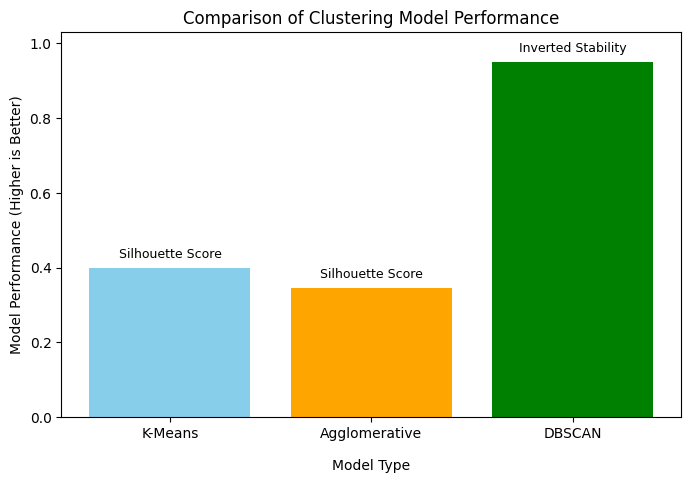

In [35]:
# Visualize DBSCAN vs K-Means and Agglomerative clustering performancee

import matplotlib.pyplot as plt

# Invert stability so higher = better
stability_inverted = 1 / (1 + stability_km)

models = ["K-Means", "Agglomerative", "DBSCAN"]
scores = [score_kmeans, score_agg, stability_inverted]

# Colors for each bar
colors = ["skyblue", "orange", "green"]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, scores, color=colors)

# Labels on top of each bar
labels = ["Silhouette Score", "Silhouette Score", "Inverted Stability"]

for bar, label in zip(bars, labels):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylim(0, 1)  # Same scale for all three models
plt.ylim(0, 1.03)  # Extra space above DBSCAN bar so label does not get cut off
plt.xlabel("Model Type", labelpad=13)
plt.ylabel("Model Performance (Higher is Better)")
plt.title("Comparison of Clustering Model Performance")

plt.show()

In [36]:
# Comparing Chicago trends with national trends for same period

# Define national trend
national_trend = (
    df_fbi[df_fbi["year"].isin([2005, 2015, 2024])] # dataset only contains data up to 2024, so 2024 is being compared to Chicago 2025 trends
    .groupby("year")["violent_crime_rate"]
    .mean()
    .reset_index()
    .rename(columns={
        "year": "Year",
        "violent_crime_rate": "Violent Crime Rate"
    })
)

print("=== National Trend ===")
print(national_trend)


# Define chicago hotspot strength
def hotspot_strength(df, year):

    labels = df[df["year"] == year]["cluster"].values
    
    # Avoid division by zero
    if len(labels) == 0:
        return None
    
    # Proportion of non-noise points
    return (labels != -1).sum() / len(labels)


# Compute strength per year
years = [2005, 2015, 2025]

strength_dict = {
    year: hotspot_strength(df_gang, year)
    for year in years
}


# Build hotspot trend dataframe
hotspot_trend = pd.DataFrame({
    "Year": years,
    "Hotspot Strength": [strength_dict[year] for year in years]
})

print("\n=== Hotspot Trend (Chicago) ===")
print(hotspot_trend)


# Build comparison dataframe
comparison = pd.DataFrame({
    "Year": years,
    "Chicago Hotspot Strength": [strength_dict[year] for year in years],
    "National Violent Crime Rate": [
        national_trend[national_trend["Year"] == 2005]["Violent Crime Rate"].values[0],
        national_trend[national_trend["Year"] == 2015]["Violent Crime Rate"].values[0],
        national_trend[national_trend["Year"] == 2024]["Violent Crime Rate"].values[0]  # Using 2024 since dataset does not have 2025 data
    ]
})

print("\n=== Combined Comparison ===")
print(comparison)

=== National Trend ===
   Year  Violent Crime Rate
0  2005               487.6
1  2015               382.8
2  2024               359.1

=== Hotspot Trend (Chicago) ===
   Year  Hotspot Strength
0  2005          0.998780
1  2015          0.996783
2  2025          0.996825

=== Combined Comparison ===
   Year  Chicago Hotspot Strength  National Violent Crime Rate
0  2005                  0.998780                        487.6
1  2015                  0.996783                        382.8
2  2025                  0.996825                        359.1


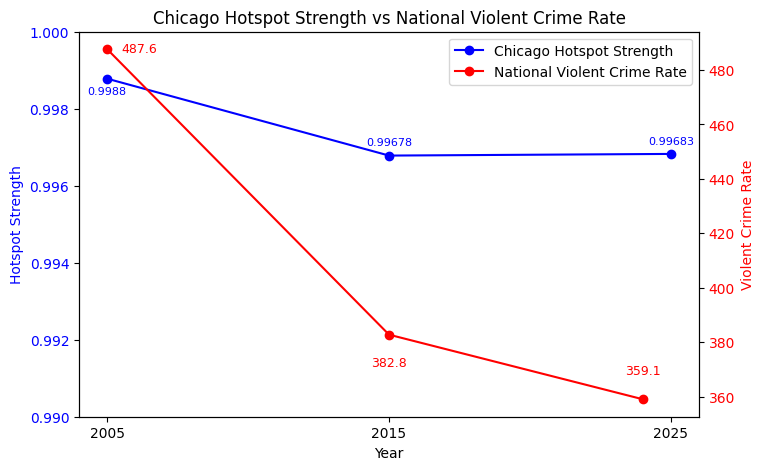

In [37]:
# Visualize comparison between Chicago crime hotspot strength and national violent crime rate over 20 years

# Data pulled from results of cell above
years_hotspot = [2005, 2015, 2025]
hotspot_strength = [0.998780, 0.996783, 0.996826]

years_violent = [2005, 2015, 2024]
national_rate = [487.6, 382.8, 359.1]

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Hotspot strength (blue)
line1 = ax1.plot(
    years_hotspot,
    hotspot_strength,
    marker='o',
    color='blue',
    label='Chicago Hotspot Strength'
)[0]

ax1.set_xlabel("Year")
ax1.set_ylabel("Hotspot Strength", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax1.set_ylim(0.990, 1.0)
ax1.set_xticks([2005, 2015, 2025])

# Hotspot labels
for x, y in zip(years_hotspot, hotspot_strength):
    if x == 2005:
        # Move 2005 hotspot label below the point
        ax1.text(
            x,
            y - 0.0002,
            f"{y:.4f}",
            ha='center',
            va='top',
            fontsize=8,
            color='blue'
        )
    else:
        # Move other hotspot labels above line
        ax1.text(
            x,
            y + 0.0002,
            f"{y:.5f}",
            ha='center',
            va='bottom',
            fontsize=8,
            color='blue'
        )

# Secondary axis
ax2 = ax1.twinx()

# Violent crime (red)
line2 = ax2.plot(
    years_violent,
    national_rate,
    marker='o',
    color='red',
    label='National Violent Crime Rate'
)[0]

ax2.set_ylabel("Violent Crime Rate", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Violent crime labels
for x, y in zip(years_violent, national_rate):
    if x == 2005:
        # Move 2005 violent crime label to the right
        ax2.text(
            x + 0.5,
            y,
            f"{y:.1f}",
            ha='left',
            va='center',
            fontsize=9,
            color='red'
        )
    elif x == 2024:
        # 2024 label above line
        ax2.text(
            x,
            y + 8,
            f"{y:.1f}",
            ha='center',
            va='bottom',
            fontsize=9,
            color='red'
        )
    else:
        # Default label below
        ax2.text(
            x,
            y - 8,
            f"{y:.1f}",
            ha='center',
            va='top',
            fontsize=9,
            color='red'
        )

# Title
plt.title("Chicago Hotspot Strength vs National Violent Crime Rate")

# Legend
ax1.legend([line1, line2],
           [line1.get_label(), line2.get_label()],
           loc='upper right')

plt.show()